In [1]:
# import bibliotecas de webscraping
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import re


In [2]:
# Extração - URL

url = 'https://www.balaroti.com.br/porcelanato-e-revestimento?termoBusca=porcelanato&filtro=Marcas__Portinari&filtro=Marcas__Portobello&filtro=Marcas__Eliane&pagina=1&tamanho=500'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

products = soup.find_all('div', class_='flex flex-col justify-start items-center group text-system-neutral-darkest max-w-60')



In [3]:
# Extração - Parse URL

soup = BeautifulSoup(response.text, 'html.parser')
products = soup.find_all('div', class_='flex flex-col justify-start items-center group text-system-neutral-darkest max-w-60')

data = []
for product in products:
    #data pesquisada hoje
    name = product.find('h3', class_='product-name-shelf-home text-2xs lg:text-sm font-medium lg:mb-2.5 mb-2 wrap-anywhere').text.strip()
    price = product.find('h2', class_='lg:text-xl text-base font-semibold wrap-anywhere').text.strip()
    data.append({'name': name, 'price': price})

df = pd.DataFrame(data)


In [4]:
# Transformação - Limpeza e Enriquecimento de Dados

df['search Date'] = pd.to_datetime('today').date()
df['price numeric'] = df['price'].str.replace('R$', '').str.replace('.', '').str.replace(',', '.').str.replace(' à vista','').str.replace(' m²','').astype(float)
df['company'] = df['name'].apply(lambda x: 'Portinari' if 'Portinari' in x else ('Portobello' if 'Portobello' in x else ('Eliane' if 'Eliane' in x else 'Other')))


def classify_product_type(name):
    if 'brilhante' in name.lower() or 'brilho' in name.lower():
        return 'Brilhante'
    elif 'acetinado' in name.lower():
        return 'Acetinado'
    elif 'polido' in name.lower():
        return 'Polido'
    elif 'natural' in name.lower() or 'nat ' in name.lower():
        return 'Natural'
    elif 'mate' in name.lower() or 'matte' in name.lower():
        return 'Mate'
    elif 'externo' in name.lower() or 'ext ' in name.lower():
        return 'Externo'
    elif 'hard' in name.lower():
        return 'Hard'
    else:
        return 'Desconhecido'


def extract_area(name):
    match = re.search(r'(\d{1,3}(?:,\d)?x\d{1,3}(?:,\d)?)', name)
    if match:
        return match.group(1).replace(',', '.')
    else:
        return 'Desconhecido'


df['product type'] = df['name'].apply(classify_product_type)
df['area'] = df['name'].apply(extract_area)

In [5]:
# Transformação - Confere se o arquivo existente já possui pesquisa na data de hoje, caso contrário, salva o arquivo atualizado junto com os dados anteriores
try:
    df_existing = pd.read_csv('porcelanato_data.csv')
    df_existing['search Date'] = pd.to_datetime(df_existing['search Date']).dt.date
    if df_existing['search Date'].iloc[-1] == pd.to_datetime('today').date():
        print("Os dados já foram atualizados hoje.")
    else:
        df_combined = pd.concat([df_existing, df], ignore_index=True)
        df_combined.to_csv('porcelanato_data.csv', index=False)
        print("Dados atualizados e salvos com sucesso.")
except FileNotFoundError:
    df.to_csv('porcelanato_data.csv', index=False)
    print("Arquivo criado e dados salvos com sucesso.")


Dados atualizados e salvos com sucesso.


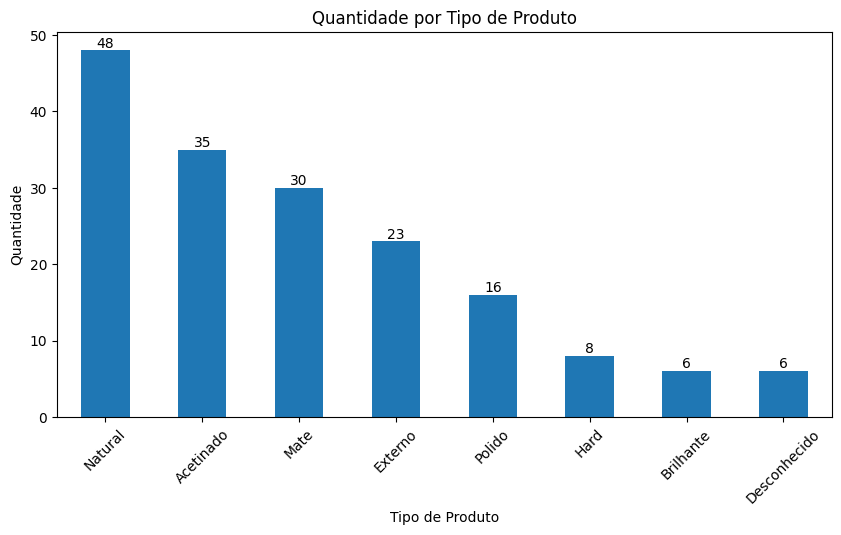

In [6]:
# Analise - Gráfico de Barras Tipo de Produto
import matplotlib.pyplot as plt

product_type_counts = df['product type'].value_counts()
plt.figure(figsize=(10, 5))
product_type_counts.plot(kind='bar')
plt.title('Quantidade por Tipo de Produto')
plt.xlabel('Tipo de Produto')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
# label de quantidade em cima de cada barra
for index, value in enumerate(product_type_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()